# From notebooks to a full pipeline: [popgen-npe](https://github.com/kr-colab/popgen-npe)

In this final notebook we shift from hand-rolled NPE on toy demographies to a **research-grade pipeline**. 

We will walk through the [popgen-npe Soup-to-Nuts tutorial](https://popgen-npe.readthedocs.io/en/latest/tutorial.html), a 6-step recipe for inferring **recombination rate and mutation rate landscapes** along a chromosome, and run the prediction step live against a pre-trained checkpoint shipped with this repository.

> **What you'll do:** 
> - inspect the simulator, processor, and YAML config that define the run
> - understand what `training_workflow.smk` would do (we don't retrain in-session)
> - run `prediction_workflow.smk` against an example VCF
> - load the resulting per-window posterior samples and plot the inferred rate landscapes

The trick that makes this work: we **train** on 500 kb windows simulated with a single, *constant* pair of rates drawn from the prior, then **predict** window-by-window on a VCF whose rates *vary spatially*. Each window is scored independently, and stitching the per-window posteriors back together gives the landscape.

In [51]:
# --- environment check -------------------------------------------------
import importlib
import shutil

PACKAGES = [
    "msprime", "tskit", "torch", "sbi", "numpy", "matplotlib",
    "zarr", "numcodecs", "dinf", "allel", "tsinfer", "pysam",
    "lightning", "ray", "pandas", "seaborn", "yaml",
    "stdpopsim", "demes", "snakemake",
]
CLI_TOOLS = ["snakemake", "vcf2zarr", "tabix"]

missing_pkgs = []
for name in PACKAGES:
    try:
        mod = importlib.import_module(name)
        print(f"  ok      {name:<12} {getattr(mod, '__version__', '?')}")
    except ImportError:
        missing_pkgs.append(name)
        print(f"  MISSING {name}")

print()
missing_cli = [t for t in CLI_TOOLS if shutil.which(t) is None]
for tool in CLI_TOOLS:
    print(f"  {'ok     ' if shutil.which(tool) else 'MISSING'} {tool} (CLI)")

if missing_pkgs or missing_cli:
    print(
        "\nSome dependencies are missing. Run:\n"
        "    conda env update -f requirements.yaml --prune\n"
        "Reading through Steps 1-3 still works; running them does not."
    )
else:
    print("\nEnvironment looks complete.")

  ok      msprime      1.4.2
  ok      tskit        1.0.3
  ok      torch        2.13.0
  ok      sbi          0.27.0
  ok      numpy        2.4.6
  ok      matplotlib   3.11.1
  ok      zarr         2.18.7
  ok      numcodecs    0.15.1
  ok      dinf         0.5.0
  ok      allel        1.3.13
  ok      tsinfer      0.5.1
  ok      pysam        0.24.0
  ok      lightning    2.6.5
  ok      ray          2.56.1
  ok      pandas       3.0.5
  ok      seaborn      0.13.2
  ok      yaml         6.0.3
  ok      stdpopsim    0.3.0
  ok      demes        0.2.3
  ok      snakemake    9.25.1

  ok      snakemake (CLI)
  ok      vcf2zarr (CLI)
  ok      tabix (CLI)

Environment looks complete.


In [52]:
# --- repository root on sys.path ---------------------------------------
# `from workflow.scripts.ts_simulators import ...` only resolves if the repo
# root is importable. Jupyter's working directory depends on how you launched
# it, so locate the root by walking up until we see workflow/scripts/.
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "workflow" / "scripts" / "ts_simulators.py").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError(
            "Could not locate the repository root: no workflow/scripts/ts_simulators.py "
            "in any parent of the current working directory."
        )
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("repo root:", REPO_ROOT)

repo root: /Users/yuxinning/Projects/SBI_ECCB2026


## What we just practiced
- Defined priors using the framework provided by `sbi` over demographic parameters (Ne, recombination) and simulators (`msprime`) to generate training data $\theta$. 
- Built summary statistics (SFS) as training data $x$. So that we have parameter pairs $(\theta, x)$.
- Trained NPE to recover posteriors $p(\theta \mid x_o)$ given observation $x_o$.
- Explored calibration/fit checks (PPC, SBC) and the effect of priors and simulator choices.
- Saw how demographic complexity (multiple epochs, recombination, etc.) reshapes the summaries we pass into NPE.

All in all, we now have a general knowledge about the `sbi` package and `msprime` simulation.

## Why a workflow?
Interactive notebooks are great for intuition and prototyping, but real projects often need reproducible, scalable runs: consistent environments, large simulation budgets, checkpoints, and logs.

A workflow system coordinates simulations, training, diagnostics, and plotting so you can rerun or extend experiments without manual steps.

## What popgen-npe provides
- A Snakemake pipeline that wires together **simulation, summary stats extraction, NPE training, and diagnostics**.
- Priors and simulators defined in **configs (YAML files)** so you can swap demographic models, summary stats, or density estimators without editing code.
- Resource-aware execution: run locally or on clusters/SLURM with the same recipes.
- Logging and checkpoints: simulation caches, training logs, and reproducible outputs.

## What we are building: mutation and recombination rate landscapes

The Soup-to-Nuts tutorial trains an NPE that, given the genotype matrix of a 500 kb genomic window, returns a **joint posterior over two parameters**: 
- the local recombination rate $r$
- the local mutation rate $\mu$. 

Sliding that estimator along a chromosome yields **rate landscapes**: a per-window posterior for each parameter, which we summarise (median plus a 90% credible interval) and plot against genomic position.

Both rates get a $\mathrm{Uniform}(10^{-9}, 10^{-7})$ prior: two orders of magnitude, covering the biologically relevant range for most eukaryotes.

Conceptually the pipeline is:

```
parameter prior (BoxUniform over (r, mu))
       │
       ▼
msprime simulator  ──►  tree sequence  ──►  processor (genotype tensor)
                                                       │
                                                       ▼
                                          embedding network + normalising flow
                                                       │
                                                       ▼
                                        posterior  p(r, mu | x_window)
```

Two constraints tie the pieces together, and both bite if you get them wrong:

- the simulator's `sequence_length` **must equal** the window size in the prediction BED file — the network only ever sees data at one scale;
- the number of samples in the VCF (after applying the population map) **must exactly match** the simulator's `samples` config.

The 6 steps below mirror the tutorial. Steps 1–4 are configuration we set up *before* the workshop; Step 5 runs live on a small example VCF; Step 6 visualises the result.

## Step 1 — Write the simulator

popgen-npe ships several simulators (`recombination_rate`, `VariablePopulationSize`, `AraTha_2epoch`, …) and lets you subclass `BaseSimulator` to add new ones. For rate-landscape inference the tutorial uses a single-population constant-size model with two inferred parameters, $r$ and $\mu$.

> Every simulator must:
> 1. inherit from `BaseSimulator`;
> 2. define a `default_config` dict whose keys are either **fixed** parameters (single values) or **random** parameters (two-element `[low, high]` lists giving uniform prior bounds);
> 3. build `self.parameters` (an ordered list of the random parameter names) and `self.prior` (a `BoxUniform` over those ranges) in `__init__`;
> 4. implement `__call__(self, seed) -> (tskit.TreeSequence, np.ndarray)`, which samples parameters, simulates a tree sequence with mutations, and returns both.

The class below has been added to `workflow/scripts/ts_simulators.py` in this repository. 
`workflow/scripts/ts_simulators.py` is what Snakemake imports when it resolves `class_name: "MutRecRate"` from the YAML, so a class defined *only* in a notebook would be invisible to the pipeline. We reproduce it here because it is worth reading once: every field in `default_config` is something the YAML in Step 3 is allowed to override.

Two details that are easy to miss:

- **`self.parameters` fixes the column order** of the returned `theta`, and that order propagates to training targets, posterior samples, and every diagnostic plot.
- **the population is named `"pop"` which is a string, not an integer.** The prediction pipeline matches VCF samples to simulator populations by name via `popmap.yaml`, so an integer-keyed population breaks Step 5.

In [53]:
import msprime
import numpy as np
import matplotlib.pyplot as plt

import torch
import tskit
from sbi.utils import BoxUniform

from workflow.scripts.ts_simulators import BaseSimulator


class MutRecRate(BaseSimulator):
    """
    Constant-size population with variable mutation and recombination
    rates. Designed for windowed estimation of rate landscapes: we train
    on single windows with constant rates, then predict per-window on
    real data.
    """

    default_config = {
        # Fixed parameters
        "samples": {"pop": 20},
        "sequence_length": 500000,
        "pop_size": 10000,
        # Random parameters — [low, high] uniform prior bounds
        "recombination_rate": [1e-9, 1e-7],
        "mutation_rate": [1e-9, 1e-7],
    }

    def __init__(self, config: dict):
        super().__init__(config, self.default_config)
        self.parameters = ["recombination_rate", "mutation_rate"]
        self.prior = BoxUniform(
            low=torch.tensor([self.recombination_rate[0],
                              self.mutation_rate[0]]),
            high=torch.tensor([self.recombination_rate[1],
                               self.mutation_rate[1]]),
        )

    def __call__(self, seed: int = None) -> (tskit.TreeSequence, np.ndarray):
        torch.manual_seed(seed)
        theta = self.prior.sample().numpy()
        recomb_rate, mut_rate = theta

        # the population must be *named* so that popmap.yaml can match it
        demography = msprime.Demography()
        demography.add_population(name="pop", initial_size=self.pop_size)

        ts = msprime.sim_ancestry(
            samples={"pop": self.samples["pop"]},
            demography=demography,
            sequence_length=self.sequence_length,
            recombination_rate=recomb_rate,
            random_seed=seed,
        )
        ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=seed)

        return ts, theta

In [54]:
# --- quick sanity check ------------------------------------------------
# Import the *installed* class (the one Snakemake will use) rather than the
# notebook copy above, so this doubles as a check that Step 1 landed.
from workflow.scripts.ts_simulators import MutRecRate as InstalledMutRecRate

sim = InstalledMutRecRate({"class_name": "MutRecRate"})
ts, theta = sim(seed=42)

print("Parameters:", dict(zip(sim.parameters, theta)))
print("Num sites: ", ts.num_sites)
print("Num trees: ", ts.num_trees)
print("Num samples:", ts.num_samples, f"({ts.num_individuals} diploid individuals)")

Parameters: {'recombination_rate': np.float32(8.8344656e-08), 'mutation_rate': np.float32(9.158539e-08)}
Num sites:  7925
Num trees:  6468
Num samples: 40 (20 diploid individuals)


## Step 2 — Configure the processor

Processors turn tree sequences into the tensors the embedding network consumes. 

Here we use the built-in `cnn_extract`, which wraps `dinf`'s haplotype-matrix feature extractor and produces an array of shape `(2, n_individuals, n_snps)` for a single population: the two channels being **SNP positions** and **genotype values**. `ExchangeableCNN` expects exactly this layout, which is why the two are paired. (See the [processor–network compatibility table](https://popgen-npe.readthedocs.io/en/latest/processors.html) for the other valid combinations.)

Although `cnn_extract` already lives in `workflow/scripts/ts_processors.py`, you can write your own processor the same way you wrote the simulator. The processor's `default_config` lists every knob, and the YAML in Step 3 only overrides the ones we care about.

One choice worth flagging: **`maf_thresh: 0.0`**. Most analyses filter out rare variants, but here the full site frequency spectrum (singletons included) is precisely what carries the mutation-rate signal, so we keep everything. Note also that `polarised` must be `False`: `cnn_extract` does not implement polarised features and will raise if you set it.

In [55]:
# This is the dict that goes into the YAML under `processor:`.
PROCESSOR_CONFIG = {
    "class_name": "cnn_extract",  # dinf haplotype matrix -> (2, n_individuals, n_snps)
    "n_snps": 1000,               # maximum number of SNPs to retain per window
    "maf_thresh": 0.0,            # 0.0 keeps ALL sites; rare variants inform the mutation rate
    "phased": False,              # collapse haplotypes to diploid genotypes
    "polarised": False,           # must be False for cnn_extract
}

from workflow.scripts.ts_processors import cnn_extract

print("cnn_extract defaults vs. our overrides:")
for key, value in cnn_extract.default_config.items():
    override = PROCESSOR_CONFIG.get(key, "(default)")
    print(f"  {key:<12} default={value!r:<8} ours={override!r}")

# Live shape check: the processor output must match the embedding network's
# input_rows / input_cols in the YAML, or training fails on the first batch.
try:
    processor = cnn_extract(PROCESSOR_CONFIG)
    features = processor(ts)  # `ts` comes from the Step 1 sanity check above
    print("\nfeature shape:", features.shape, "-> (channels, individuals, snps)")
    print("=> embedding_network input_rows:", [features.shape[1]],
          "input_cols:", [features.shape[2]])
except (ImportError, NameError) as err:
    print(f"\nSkipping live shape check ({type(err).__name__}: {err})")
    print("Expected shape for this config: (2, 20, 1000)")

cnn_extract defaults vs. our overrides:
  n_snps       default=500      ours=1000
  phased       default=False    ours=False
  maf_thresh   default=0.05     ours=0.0
  polarised    default=False    ours=False

feature shape: (2, 20, 1000) -> (channels, individuals, snps)
=> embedding_network input_rows: [20] input_cols: [1000]


## Step 3 — Write the config YAML

The full run is described by one YAML file. It collects the simulator and processor blocks above plus training hyperparameters, resource limits, and (for prediction) the VCF + BED-window inputs. The same file is consumed by both `training_workflow.smk` and `prediction_workflow.smk`, which is what guarantees that prediction-time tree sequences are processed identically to training-time ones.

The workflow derives its output directory from the config rather than from a name you pick, using the scheme

```
{simulator}-{processor}-{embedding}-{random_seed}-{n_train}-{sep|e2e}
```

so this config writes into `MutRecRate-cnn_extract-ExchangeableCNN-42-5000-sep/` underneath `project_dir`. Change `random_seed` or `n_train` and you get a fresh directory rather than a silent overwrite.

Our config lives at `workflow/config/MutRecRate_cnn.yaml`, with `project_dir` pointing at `notebooks/popgen_npe_demo/` — so the trained checkpoint and the prediction outputs both land next to this notebook. The cell below prints it, checks the three cross-references that have to agree, and works out where everything will be written.

In [61]:
# The full config YAML from Step 3 of the tutorial.
from pathlib import Path
import yaml

CONFIG_PATH = REPO_ROOT / "workflow" / "config" / "MutRecRate_cnn.yaml"
print(f"# {CONFIG_PATH.relative_to(REPO_ROOT)}\n")
print(CONFIG_PATH.read_text())

CONFIG = yaml.safe_load(CONFIG_PATH.read_text())

sim_cfg = CONFIG["simulator"]
proc_cfg = CONFIG["processor"]
emb_cfg = CONFIG["embedding_network"]

print("consistency checks (all three must agree, or the run breaks)")
print(f"  individuals per pop  {sim_cfg['samples']}  <->  embedding input_rows {emb_cfg['input_rows']}")
print(f"  processor n_snps     {proc_cfg['n_snps']}  <->  embedding input_cols {emb_cfg['input_cols']}")
print(f"  sequence_length      {sim_cfg['sequence_length']}  <->  window size in {CONFIG['prediction']['windows']}")


def resolve(path):
    """Paths in the config are relative to the repository root."""
    path = Path(path)
    return path if path.is_absolute() else REPO_ROOT / path


# Reproduce the naming scheme from workflow/common.smk so the later cells know
# where the workflow put things.
UID = "-".join([
    sim_cfg["class_name"],
    proc_cfg["class_name"],
    emb_cfg["class_name"],
    str(CONFIG["random_seed"]),
    str(CONFIG["n_train"]),
    "sep" if CONFIG["train_embedding_net_separately"] else "e2e",
])
PROJECT_DIR = resolve(CONFIG["project_dir"]) / UID
EMBEDDING_NET = PROJECT_DIR / "pretrain_embedding_network"
NORMALIZING_FLOW = PROJECT_DIR / "pretrain_normalizing_flow"

print(f"\noutput directory: {PROJECT_DIR.relative_to(REPO_ROOT)}")
for label, path in [("embedding network", EMBEDDING_NET), ("normalizing flow", NORMALIZING_FLOW)]:
    print(f"  {'found  ' if path.exists() else 'MISSING'} {label}: {path.name}")

# --- running Snakemake from this notebook ------------------------------
# `snakemake` is installed in this kernel's environment, but a plain
# `snakemake ...` in a terminal only works if that terminal has the env
# activated (`conda activate sbi-workshop`). Inside the notebook we can
# sidestep that: prefer the console script if it is on PATH, otherwise
# invoke the module through the interpreter running this kernel.
import shlex
import shutil
import subprocess
import sys


def snakemake_cmd(*args):
    exe = shutil.which("snakemake")
    base = [exe] if exe else [sys.executable, "-m", "snakemake"]
    return base + list(args)


def run_streaming(cmd):
    """Run a command from REPO_ROOT, echoing output into the notebook.

    subprocess.run() would send Snakemake's output to the terminal hosting
    the Jupyter server rather than to this cell, which looks like a hang on
    a job that takes many minutes.
    """
    proc = subprocess.Popen(
        cmd, cwd=REPO_ROOT, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, bufsize=1,
    )
    for line in proc.stdout:
        print(line, end="")
    code = proc.wait()
    if code != 0:
        raise subprocess.CalledProcessError(code, cmd)
    return code


print("\nsnakemake invocation:", shlex.join(snakemake_cmd()))

# workflow/config/MutRecRate_cnn.yaml

# --- top level arguments are ALWAYS REQUIRED --- #
#
# Config for the popgen-npe "Soup-to-Nuts" tutorial:
#   https://popgen-npe.readthedocs.io/en/latest/tutorial.html
#
# Trains a two-parameter NPE (recombination rate + mutation rate) on
# constant-rate 500 kb windows, then predicts per-window on a VCF whose
# rates vary spatially -- i.e. a rate landscape.
#
# All paths below are relative to the repository root; run snakemake from
# there. Outputs land in
#   notebooks/popgen_npe_demo/MutRecRate-cnn_extract-ExchangeableCNN-42-5000-sep/

project_dir: "notebooks/popgen_npe_demo"

cpu_resources: # optional, used for CPU-only tasks (simulation)
  runtime: "2h"
  mem_mb: 16000

gpu_resources: # optional, used for GPU tasks (training)
  runtime: "4h"
  mem_mb: 50000
  gpus: 1
  slurm_partition: "gpu"
  slurm_extra: "--gres=gpu:1"

random_seed: 42
n_chunk: 10 # number of jobs for parallel simulation
n_train: 5000
n_val: 500
n_test: 500

train_embedding

## Step 4 — Run the training workflow *(one-off, before the session)*

Training is the step that produces the checkpoint Step 5 loads. **The tutorial does not distribute a pre-trained model** — the only artefacts shipped upstream are the example data in `example_data/MutRecRate/` — so this workflow has to be run once, off-session, to generate it:

```bash
snakemake --cores 4 \
          --configfile workflow/config/MutRecRate_cnn.yaml \
          --snakefile workflow/training_workflow.smk
```

That triggers the full simulate → process → train pipeline:

1. **Setup** — create the Zarr store and divide the work into `n_chunk` chunks.
2. **Simulate** — draw rate pairs from the prior and simulate one constant-rate window per draw.
3. **Process** — run `cnn_extract` over every tree sequence, writing tensors into Zarr.
4. **Train embedding network** — fit the `ExchangeableCNN` that turns genotype matrices into summary statistics.
5. **Train normalizing flow** — fit the neural posterior estimator on those embeddings.
6. **Diagnostics** — calibration, concentration, and simulation-summary plots.

With `n_train: 5000` this is roughly 15 minutes on an A100 and considerably longer on CPU; simulation is the bottleneck, so raise `n_chunk` if you have cores to spare. **We do not run it live in the session.**

Once it finishes, `notebooks/popgen_npe_demo/MutRecRate-cnn_extract-ExchangeableCNN-42-5000-sep/` holds `pretrain_embedding_network` and `pretrain_normalizing_flow` — no copying required, since `project_dir` already points there. Before interpreting anything, open `plots/posterior_calibration.png` (points on the diagonal mean well-calibrated posteriors) and `plots/posterior_expectation.png` (posterior means vs. true values).

In [62]:
# Step 4 is a one-off: it generates the checkpoint that Step 5 needs.
# Flip RUN_TRAINING to True and re-run this cell to actually launch it.
RUN_TRAINING = False  # ~15 min on a GPU, considerably longer on CPU

cmd = snakemake_cmd(
    "--cores", "4",
    "--configfile", str(CONFIG_PATH),
    "--snakefile", str(REPO_ROOT / "workflow" / "training_workflow.smk"),
)
print("$", shlex.join(cmd), f"\n  (from {REPO_ROOT})\n")

if EMBEDDING_NET.exists() and NORMALIZING_FLOW.exists():
    print("Checkpoint already present -- nothing to do, skip to Step 5.")
elif RUN_TRAINING:
    run_streaming(cmd)
else:
    print("RUN_TRAINING is False, so nothing was launched.")
    print("Either set RUN_TRAINING = True and re-run this cell, or run the")
    print("command above in a terminal AFTER activating the environment:")
    print("    conda activate sbi-workshop")

$ /Users/yuxinning/miniconda3/envs/sbi-workshop/bin/snakemake --cores 4 --configfile /Users/yuxinning/Projects/SBI_ECCB2026/workflow/config/MutRecRate_cnn.yaml --snakefile /Users/yuxinning/Projects/SBI_ECCB2026/workflow/training_workflow.smk 
  (from /Users/yuxinning/Projects/SBI_ECCB2026)

Checkpoint already present -- nothing to do, skip to Step 5.


## Step 5 — Run prediction on the example data *(live)*

Prediction reuses the simulator, processor, and embedding-network sections from the same YAML. Tree sequences are now *inferred from a VCF* rather than simulated, then processed and scored by the trained flow — yielding a posterior per genomic window.

The input is `example_data/MutRecRate/`, shipped with this repository: a synthetic VCF built with `msprime.RateMap` objects so that rates vary across three 5 Mb chromosomes, plus the 30-window BED file, the population map, and the ground-truth rates. The workflow will:

1. **Convert VCF** — `vcf2zarr` turns the bgzipped VCF into a Zarr store.
2. **Setup** — check that VCF samples match the simulator, then define windows.
3. **Infer trees** — `tsinfer` reconstructs a tree sequence per window from genotypes alone.
4. **Process** — the same `cnn_extract` used in training.
5. **Predict** — draw 1,000 posterior samples per window from the trained flow.
6. **Diagnostics** — per-window posterior heatmap and tree-statistic histograms.

Note the asymmetry with training: there we had true tree sequences straight from `msprime`, here we only have genotypes and must *infer* the trees. That gap is a real source of error, which is why `plots/tree_stats_hist.png` is worth checking afterwards.

The cell below runs it. If the checkpoint from Step 4 is missing it reports exactly what it needs instead of failing partway through.

In [63]:
# Runs workflow/prediction_workflow.smk against example_data/MutRecRate/.
required = {
    "embedding network (Step 4)": EMBEDDING_NET,
    "normalizing flow (Step 4)": NORMALIZING_FLOW,
    "VCF": resolve(CONFIG["prediction"]["vcf"]),
    "population map": resolve(CONFIG["prediction"]["population_map"]),
    "windows BED": resolve(CONFIG["prediction"]["windows"]),
}
missing = {label: path for label, path in required.items() if not path.exists()}

cmd = snakemake_cmd(
    "--cores", "2",
    "--configfile", str(CONFIG_PATH),
    "--snakefile", str(REPO_ROOT / "workflow" / "prediction_workflow.smk"),
)

if missing:
    print("Skipping live prediction -- missing:")
    for label, path in missing.items():
        print(f"  - {label}: {path}")
    print("\nRun Step 4 first (training generates the checkpoint); the example")
    print("data ships with this repository under example_data/MutRecRate/.")
else:
    print("$", shlex.join(cmd), f"\n  (from {REPO_ROOT})\n")
    run_streaming(cmd)

$ /Users/yuxinning/miniconda3/envs/sbi-workshop/bin/snakemake --cores 2 --configfile /Users/yuxinning/Projects/SBI_ECCB2026/workflow/config/MutRecRate_cnn.yaml --snakefile /Users/yuxinning/Projects/SBI_ECCB2026/workflow/prediction_workflow.smk 
  (from /Users/yuxinning/Projects/SBI_ECCB2026)

Assuming unrestricted shared filesystem usage.

SNAKEMAKE
  Date: 2026-08-11 10:25:07
  Workflow ID: d6ed9b71-4bcf-4dd3-b422-88b807eaa061
  Platform: macOS-26.6.1-arm64-arm-64bit
  Host: Mac.local
  User: yuxinning
  Snakemake version: 9.25.1
  Python version: 3.12.13 | packaged by conda-forge | (main, Mar  5 2026, 17:06:14) [Clang 19.1.7 ]
  Command: /Users/yuxinning/miniconda3/envs/sbi-workshop/bin/snakemake --cores 2 --configfile /Users/yuxinning/Projects/SBI_ECCB2026/workflow/config/MutRecRate_cnn.yaml --snakefile /Users/yuxinning/Projects/SBI_ECCB2026/workflow/prediction_workflow.smk
  Snakefile: /Users/yuxinning/Projects/SBI_ECCB2026/workflow/prediction_workflow.smk
  Base directory: /Users/

## Step 6 — Interpret the results: the rate landscapes

The prediction workflow writes 1,000 posterior draws per window into the Zarr store at `tensors/zarr/predictions`, as an array of shape `(n_windows, n_parameters, n_samples)`. The parameter axis follows `self.parameters` from Step 1 — index 0 is the recombination rate, index 1 the mutation rate.

We load those draws, summarise each window by its posterior median and a 90% credible interval, and plot the result against the ground truth in `example_data/MutRecRate/true_rates.tsv`. The example VCF was built so the rates vary in a known way: chr0 has varying recombination but constant mutation, chr1 the reverse, and chr2 both varying in opposite directions. That design makes it easy to see whether the model separates the two signals or confuses them.

Two artefacts the workflow produces are worth opening alongside this plot:

- `plots/posteriors-across-windows.png` — the workflow's own per-window posterior heatmap, with chromosome boundaries marked.
- `plots/tree_stats_hist.png` — summary statistics of the *inferred* tree sequences against the simulated training data. If the real data falls outside the training range, the posteriors are extrapolations and should not be trusted.

posterior samples: (30, 2, 1000) (windows, parameters, draws)


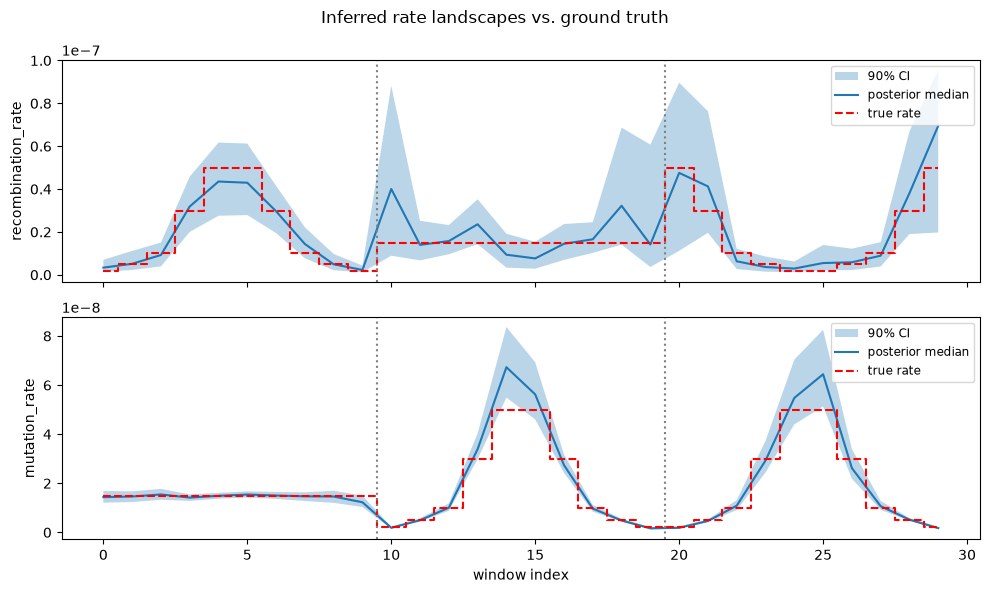

In [64]:
# --- Step 6: load per-window posteriors and plot the rate landscapes ----
import numpy as np
import matplotlib.pyplot as plt

PARAM_NAMES = ["recombination_rate", "mutation_rate"]  # order set by sim.parameters

vcf_path = resolve(CONFIG["prediction"]["vcf"])
PRED_ZARR = PROJECT_DIR / vcf_path.name / "tensors" / "zarr" / "predictions"
TRUE_RATES = vcf_path.parent / "true_rates.tsv"
BED = resolve(CONFIG["prediction"]["windows"])

if not PRED_ZARR.exists():
    print(f"No predictions found at:\n  {PRED_ZARR}")
    print("\nRun Step 5 first (which needs the Step 4 checkpoint).")
else:
    import zarr

    predictions = zarr.load(str(PRED_ZARR))  # (n_windows, n_parameters, n_samples)
    n_windows = predictions.shape[0]
    windows = np.arange(n_windows)
    print("posterior samples:", predictions.shape, "(windows, parameters, draws)")

    truth = np.loadtxt(TRUE_RATES, skiprows=1, usecols=[3, 4]) if TRUE_RATES.exists() else None
    if truth is not None and truth.shape[0] != n_windows:
        # low-density windows are dropped by min_snps_per_window, so the
        # ground truth can be longer than the prediction array
        print(f"note: {truth.shape[0]} true rates vs {n_windows} predicted windows "
              "-- some windows were filtered out; not overlaying truth")
        truth = None

    # chromosome boundaries, read off the BED file so this generalises
    boundaries = []
    if BED.exists():
        chrom = np.loadtxt(BED, usecols=[0], dtype=object)
        if len(chrom) == n_windows:
            boundaries = [i for i in range(1, len(chrom)) if chrom[i] != chrom[i - 1]]

    fig, axes = plt.subplots(len(PARAM_NAMES), 1, figsize=(10, 6), sharex=True)
    axes = np.atleast_1d(axes)
    for i, (ax, name) in enumerate(zip(axes, PARAM_NAMES)):
        draws = predictions[:, i, :]
        ax.fill_between(windows,
                        np.quantile(draws, 0.05, axis=1),
                        np.quantile(draws, 0.95, axis=1),
                        alpha=0.3, label="90% CI")
        ax.plot(windows, np.median(draws, axis=1), label="posterior median")
        if truth is not None:
            ax.step(windows, truth[:, i], where="mid",
                    color="red", linestyle="--", label="true rate")
        for b in boundaries:
            ax.axvline(b - 0.5, color="gray", linestyle=":")
        ax.set_ylabel(name)
        ax.legend(loc="upper right", fontsize="small")

    axes[-1].set_xlabel("window index")
    fig.suptitle("Inferred rate landscapes vs. ground truth")
    fig.tight_layout()
    fig.savefig(REPO_ROOT / "notebooks" / "popgen_npe_demo" / "rate_landscape.png", dpi=150)
    plt.show()

## Next steps and scaling to real data

Once you've reproduced the demo, the natural extensions are:

- **Swap the simulator** for a model that matches your study system (e.g., a two-epoch demography, or a multi-population split). See `simulators.html` for the menu and the "Creating Custom Simulators" recipe.
- **Swap the processor** to change the summary the network sees — `tskit_sfs` for an SFS-based run, `tskit_windowed_sfs_plus_ld` to add LD information, `cnn_extract` for raw genotype matrices.
- **Scale up training** by raising `n_train` and pushing the run to a cluster: Snakemake's SLURM profile is configured directly in the YAML's `gpu_resources` and `cpu_resources` blocks.
- **Validate before interpreting** — re-use the PPC and SBC machinery from notebooks 3 and 4 against held-out posterior draws before treating the rate landscape as ground truth.
- **Contribute back.** New simulators, processors, and bug fixes are welcome via the [popgen-npe contributor guide](https://popgen-npe.readthedocs.io/en/latest/contributing.html).

That's the bridge from the tutorial notebooks to a real-world NPE pipeline. Explore the popgen-npe repo and configs to continue experimenting beyond this session.